# 🧠 Recurrent Neural Network (RNN)

## 📌 What is an RNN?

A **Recurrent Neural Network (RNN)** is a type of artificial neural network where connections between nodes form a **directed cycle**, allowing it to retain a **memory of previous inputs**. It's widely used for sequential data.

---

## 💡 Why RNNs are Needed

Traditional feedforward networks assume all inputs are **independent**, but many tasks involve **context and order**:

- 📈 Time series forecasting
- 📝 Text generation and translation
- 🗣️ Speech recognition
- 🎬 Video analysis

RNNs maintain a hidden state that captures information from previous steps, allowing the model to **learn temporal dependencies**.

---

## ⚙️ Working of RNN

At each time step \( t \), RNN updates its hidden state and generates output.

### Variables:

- \( x_t \): Input at time step \( t \)
- \( h_t \): Hidden state at time \( t \)
- \( y_t \): Output at time \( t \)

### Formulas:

1. **Hidden state update**:

   $$
   h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b_h)
   $$

2. **Output**:

   $$
   y_t = W_{hy} \cdot h_t + b_y
   $$

Where:
- \( W_{xh}, W_{hh}, W_{hy} \) are weight matrices
- \( b_h, b_y \) are bias vectors
- \( \tanh \) is the hyperbolic tangent activation function

---

## 🧱 RNN Architecture

```
x_1 ─┬──────────────┐
     ▼              ▼
   [RNN Cell] → [RNN Cell] → ... → [RNN Cell]
     │              │               │
     ▼              ▼               ▼
    h_1            h_2             h_t
     │              │               │
     ▼              ▼               ▼
    y_1            y_2             y_t
```

Each cell takes:
- Current input \( x_t \)
- Previous hidden state \( h_{t-1} \)

Produces:
- New hidden state \( h_t \)
- Output \( y_t \)

---

## 🔁 Types of RNN Architectures

| Type         | Description                                  |
|--------------|----------------------------------------------|
| One-to-One   | Traditional NN (e.g., image classification)  |
| One-to-Many  | Image captioning                             |
| Many-to-One  | Sentiment analysis                           |
| Many-to-Many | Machine translation, speech recognition      |

---

## ⚠️ Limitations of Vanilla RNN

- **Vanishing Gradient Problem**:
  Gradients shrink over long sequences:
  $$
  \frac{\partial L}{\partial W} \to 0
  $$
  making it hard to learn long-term dependencies.

- **Exploding Gradient Problem**:
  Gradients grow uncontrollably:
  $$
  \frac{\partial L}{\partial W} \to \infty
  $$

---

## 🔄 Solution: RNN Variants

### ✅ LSTM (Long Short-Term Memory)
- Uses **gates**: forget, input, output
- Maintains **cell state** for long-term memory

### ✅ GRU (Gated Recurrent Unit)
- Simpler than LSTM
- Uses **update** and **reset** gates

---

## 🛠 Applications of RNNs

- 🗣️ Speech-to-text
- 🧠 Language modeling (e.g., GPT)
- 🔤 Machine translation
- ✍️ Handwriting recognition
- 📈 Stock price prediction
- 🎼 Music generation

---

## 🧪 Sample PyTorch Code

```python
import torch
import torch.nn as nn

class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)         # (batch, seq_len, hidden_size)
        out = self.fc(out[:, -1, :]) # Last time-step
        return out
```

---

## 📚 Summary

- RNNs process **sequences step-by-step**
- Maintain **hidden state memory**
- Useful for time and order-based data
- Suffer from gradient issues
- Use **LSTM** or **GRU** to handle long-term dependencies

---


### RNN for stock price prediction

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def generate_stock_data(n_samples=500, seq_len=10):
    x = np.linspace(0, 50, n_samples + seq_len)
    prices = np.sin(x) + 0.1 * np.random.randn(len(x))
    X, y = [], []
    for i in range(n_samples):
        X.append(prices[i:i+seq_len])
        y.append(prices[i+seq_len])
    return np.array(X), np.array(y)

X, y = generate_stock_data()


In [4]:
import torch

X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (batch, seq_len, 1)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (batch, 1)

train_size = int(len(X) * 0.8)
X_train, X_test = X_tensor[:train_size], X_tensor[train_size:]
y_train, y_test = y_tensor[:train_size], y_tensor[train_size:]


In [5]:
import torch.nn as nn

class StockRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super(StockRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        out, _ = self.rnn(x)  # out: [batch, seq_len, hidden]
        out = out[:, -1, :]   # last timestep
        return self.fc(out)


In [6]:
model = StockRNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

losses = []
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())


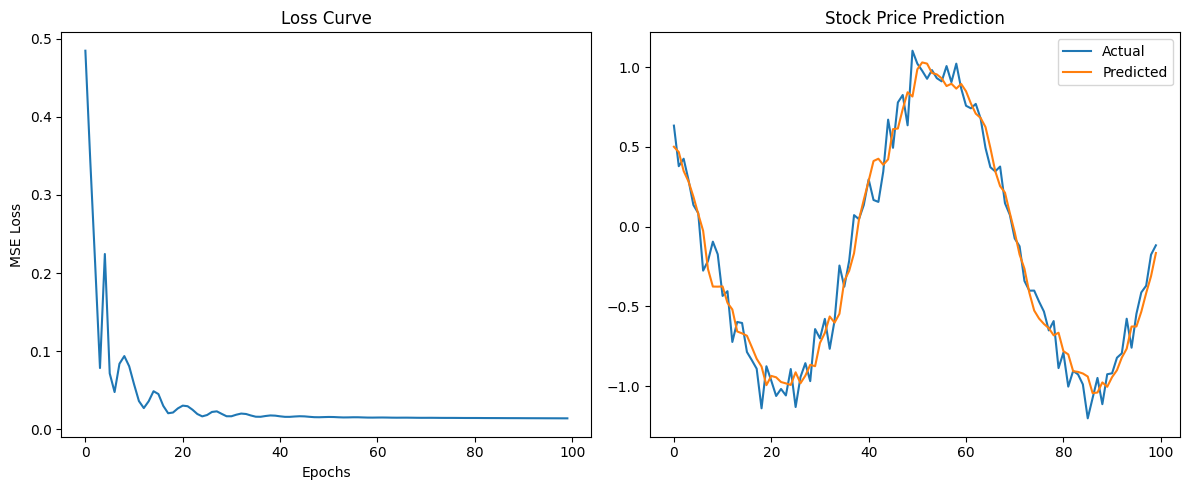

In [7]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")

plt.subplot(1, 2, 2)
plt.plot(y_test.numpy(), label="Actual")
plt.plot(predictions.numpy(), label="Predicted")
plt.title("Stock Price Prediction")
plt.legend()

plt.tight_layout()
plt.show()
